**DL_PA2   Roll_Number 25280103:     In this we have to check the model accurac by using the different optimization and genalization techniques: And try to increase the model accuracy by using different methods and techniques**

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [17]:
##Loading the data
train_data = np.load("processed_data/quickdraw_train.npz")
test_data = np.load("processed_data/quickdraw_test.npz")

print("Train keys:", train_data.files)
print("Test keys:", test_data.files)

Train keys: ['x_train', 'y_train', 'class_names']
Test keys: ['test_images']


In [18]:
#extract Arrays
# Extract arrays correctly

X_train = train_data['x_train']
y_train = train_data['y_train']
class_names = train_data['class_names']

X_test = test_data['test_images']

print("Train shape:", X_train.shape)
print("Labels shape:", y_train.shape)
print("Test shape:", X_test.shape)
print("Number of classes:", len(class_names))

Train shape: (60000, 784)
Labels shape: (60000,)
Test shape: (15000, 784)
Number of classes: 15


In [19]:
#preprocessing the data for training and testing
# Normalize pixel values to [0,1]

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min value:", X_train.min())
print("Max value:", X_train.max())

Min value: 0.0
Max value: 1.0


In [20]:
# Convert to PyTorch tensors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)

print("Tensor shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

Using device: cpu
Tensor shapes:
X_train: torch.Size([60000, 784])
y_train: torch.Size([60000])
X_test: torch.Size([15000, 784])


In [21]:
#this was giving the 77 to 80% accuracy, now i will use the augmentation to see if it can improve the accuracy
import torchvision.transforms as transforms

# Define augmentation
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor()
])

In [22]:
from torch.utils.data import Dataset

class AugmentedDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].reshape(28, 28)
        label = self.y[idx]

        if self.augment:
            image = transform(image.numpy().astype('float32'))
            image = image.view(-1)
        else:
            image = torch.tensor(image, dtype=torch.float32).view(-1)

        return image, label

In [23]:
train_dataset = AugmentedDataset(X_train, y_train, augment=True)
val_dataset = AugmentedDataset(X_train[48000:], y_train[48000:], augment=False)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)

""Part 1 Pencake Wise Model where we used the multiple neurons but less number of hidden layers""

In [24]:
# PART A — Pancake Model (Wide, Shallow)

class PancakeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 15)
        )

    def forward(self, x):
        return self.model(x)

pancake = PancakeMLP().to(device)

# Count parameters
total_params = sum(p.numel() for p in pancake.parameters())
print("Pancake parameter count:", total_params)

Pancake parameter count: 1868815


**Model Tranining**
Training Function in which use different types of optimizers and also the lr: 
First used the lr=0.001 and weight decay: 1e-4;    and 35 epchos optimizer used the adam:   
It gave the accuracy 79% and but traning 99 percentage: 

**Model Traning second time and Function**
Decrease the learning rate to 0.0007: increse the capacity:    and weight decay kept same: epochos same:    And used the schedulere optimizer:   same used the batch normalization and also the Gel function and dropout from 0.25 to 0.35: but it gave the accuracy slightly increase to 80% 

**Model Traning 3rd time and optimizations**
Learning rate more decrese used the 0.0005: But still it gave the 80% and used the weight_decay of 5e-4: And epchos 38: In this time i observe that traning increased slowly and also the val increse with it but training went to 99% but the val still quite on the 80%: now im thinking that i should add the regularization and also this time i decreased the data but still it gave the same accuracy: And i also thinking that i should change the optimization techinque this time...

**Model Traning and optimization 4rth time**
This time used the 40 epochs and also use the lr=0.05 and also used the 1million 65k parameters: 

**Model Traning and Optimization 4rth time B**
I minimized the learning rate to 0.0005 in the start it gave the best but after that it still showed 77% result accuracy:

**Model Traning and Optimiztion 5th time**
This time i used the augumentation for data set this gives me the underfitting and also it gave me the highest accuracy 88% and mostly more than the 80% and also used the same relu function drop affect and also the batch optimization technique: And parameters used 0.8 million and something


In [25]:
def train_model(model, epochs=40):

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.05,
        momentum=0.9,
        weight_decay=5e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    criterion = nn.CrossEntropyLoss()

    best_val = 0

    for epoch in range(epochs):

        model.train()
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_acc = correct / total

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total

        scheduler.step()

        if val_acc > best_val:
            best_val = val_acc

        print(f"Epoch {epoch+1}: Train={train_acc:.4f}, Val={val_acc:.4f}")

    print("Best Validation Accuracy:", best_val)

In [26]:
print("Training Pancake Model...")

# p_train, p_val = train_model(pancake, epochs=35)        
train_model(pancake, epochs=35)                                                                                                        

Training Pancake Model...


C:\Users\Teacher\AppData\Local\Temp\ipykernel_4516\2967252158.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).view(-1)


Epoch 1: Train=0.4167, Val=0.7189
Epoch 2: Train=0.6067, Val=0.6904
Epoch 3: Train=0.6592, Val=0.7570
Epoch 4: Train=0.6882, Val=0.7987
Epoch 5: Train=0.7040, Val=0.7192
Epoch 6: Train=0.7182, Val=0.8555
Epoch 7: Train=0.7291, Val=0.7993
Epoch 8: Train=0.7404, Val=0.7851
Epoch 9: Train=0.7504, Val=0.8535
Epoch 10: Train=0.7568, Val=0.8538
Epoch 11: Train=0.7607, Val=0.8831
Epoch 12: Train=0.7674, Val=0.8887
Epoch 13: Train=0.7725, Val=0.8334
Epoch 14: Train=0.7760, Val=0.8373
Epoch 15: Train=0.7810, Val=0.8572
Epoch 16: Train=0.7832, Val=0.8659
Epoch 17: Train=0.7879, Val=0.8528
Epoch 18: Train=0.7940, Val=0.8859
Epoch 19: Train=0.7954, Val=0.8739
Epoch 20: Train=0.7965, Val=0.8023
Epoch 21: Train=0.8018, Val=0.8623
Epoch 22: Train=0.8020, Val=0.8723
Epoch 23: Train=0.8071, Val=0.8812
Epoch 24: Train=0.8096, Val=0.8717
Epoch 25: Train=0.8107, Val=0.8407
Epoch 26: Train=0.8139, Val=0.8738
Epoch 27: Train=0.8165, Val=0.8848
Epoch 28: Train=0.8167, Val=0.8832
Epoch 29: Train=0.8213, Val=0

**As we used the higher number of so features are memorised by the neurons and in this pancake as multiple nodes used so its giving the less accuracy than the training model sever overfitting....**

**2nd Tower model in this we use the multiple hidden layers and not much the neurons... that's why its called the tower model...**

In [27]:
# PART B — Tower Model (Deep & Narrow)

class TowerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 15)
        )

    def forward(self, x):
        return self.model(x)

tower = TowerMLP().to(device)

print("Tower parameter count:", sum(p.numel() for p in tower.parameters()))

Tower parameter count: 470543


In [ ]:
#train Tower model
print("Training Tower Model...")

# t_train, t_val = train_model(tower, epochs=35)
train_model(tower, epochs=35)


Training Tower Model...


C:\Users\Teacher\AppData\Local\Temp\ipykernel_4516\2967252158.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).view(-1)


Epoch 1: Train=0.5781, Val=0.7483
Epoch 2: Train=0.6705, Val=0.8363
Epoch 3: Train=0.6962, Val=0.7391
Epoch 4: Train=0.7150, Val=0.8157
Epoch 5: Train=0.7259, Val=0.8398
Epoch 6: Train=0.7374, Val=0.8727
Epoch 7: Train=0.7440, Val=0.8331
Epoch 8: Train=0.7520, Val=0.8460
Epoch 9: Train=0.7573, Val=0.8292
Epoch 10: Train=0.7624, Val=0.8044
Epoch 11: Train=0.7677, Val=0.8538
Epoch 12: Train=0.7715, Val=0.8237
Epoch 13: Train=0.7764, Val=0.8083
Epoch 14: Train=0.7796, Val=0.8598
Epoch 15: Train=0.7827, Val=0.8742
Epoch 16: Train=0.7873, Val=0.8888
Epoch 17: Train=0.7914, Val=0.8802
Epoch 18: Train=0.7968, Val=0.8405


**For the first championFunction used the linear, optiomizaiton BatchnNorm1d, Gelu activation function and also used the dropout 0.3 and data 1.9 nodes: it gave the accuracy of 99% for the test but 79% for the validation:**

In [ ]:
class ChampionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 15)
        )

    def forward(self, x):
        return self.model(x)

champion = ChampionMLP().to(device)

print("Champion parameter count:", sum(p.numel() for p in champion.parameters()))

Champion parameter count: 802319


In [ ]:
champion = ChampionMLP().to(device)

print("Training Champion Model...")

c_train, c_val = train_model(champion, epochs=40)
# train_model(champion, epochs=35)

Training Champion Model...


C:\Users\Teacher\AppData\Local\Temp\ipykernel_4516\2967252158.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).view(-1)


Epoch 1: Train=0.5307, Val=0.7216
Epoch 2: Train=0.6255, Val=0.7843
Epoch 3: Train=0.6540, Val=0.7804
Epoch 4: Train=0.6678, Val=0.7934
Epoch 5: Train=0.6834, Val=0.7980
Epoch 6: Train=0.6950, Val=0.7887
Epoch 7: Train=0.7020, Val=0.8327
Epoch 8: Train=0.7106, Val=0.8443
Epoch 9: Train=0.7177, Val=0.8166
Epoch 10: Train=0.7234, Val=0.8300
Epoch 11: Train=0.7282, Val=0.8213
Epoch 12: Train=0.7331, Val=0.7769
Epoch 13: Train=0.7371, Val=0.8501
Epoch 14: Train=0.7424, Val=0.8194
Epoch 15: Train=0.7460, Val=0.8642
Epoch 16: Train=0.7478, Val=0.8399
Epoch 17: Train=0.7533, Val=0.8360
Epoch 18: Train=0.7541, Val=0.8538
Epoch 19: Train=0.7570, Val=0.8407
Epoch 20: Train=0.7621, Val=0.8710
Epoch 21: Train=0.7628, Val=0.8753
Epoch 22: Train=0.7673, Val=0.8545
Epoch 23: Train=0.7675, Val=0.8573
Epoch 24: Train=0.7723, Val=0.8580
Epoch 25: Train=0.7754, Val=0.8572
Epoch 26: Train=0.7751, Val=0.8720
Epoch 27: Train=0.7785, Val=0.8514
Epoch 28: Train=0.7797, Val=0.8614
Epoch 29: Train=0.7859, Val=0

TypeError: cannot unpack non-iterable NoneType object

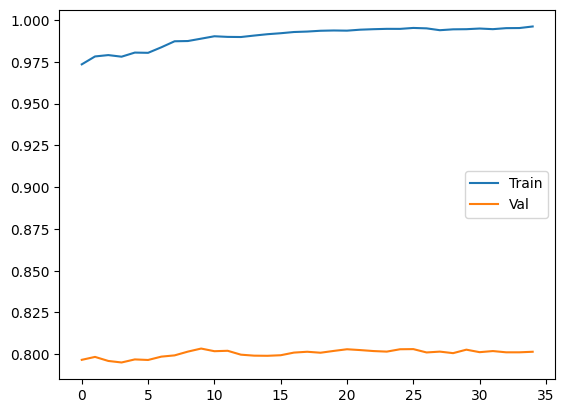

In [ ]:
#Plot Curves
plt.plot(c_train, label="Train")
plt.plot(c_val, label="Val")
plt.legend()
plt.show()

C:\Users\Teacher\AppData\Local\Temp\ipykernel_15580\2967252158.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).view(-1)


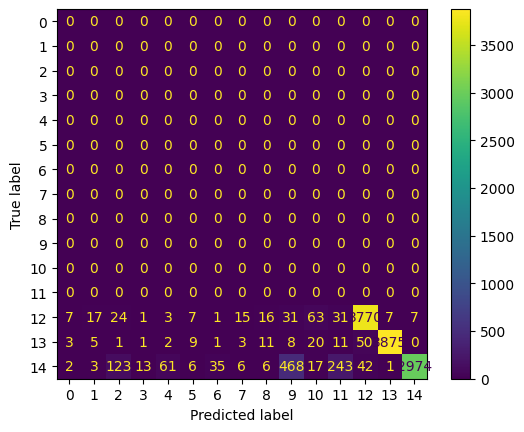

In [ ]:
#Confusion Matrix
champion.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in val_loader:
        outputs = champion(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [ ]:
#save the bestModel
torch.save(champion.state_dict(), "best_model.pth")

In [ ]:
#Generate test prediction
champion.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    outputs = champion(X_test_tensor)
    preds = torch.argmax(outputs, dim=1)

np.savetxt("submission.csv", preds.numpy(), fmt="%d", delimiter=",")

C:\Users\Teacher\AppData\Local\Temp\ipykernel_15580\4027761751.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
